# Fig: MET against coupling strength
Networked cases

ISHII Hidemasa

In [1]:
using Statistics, CSV, DataFrames, DataFramesMeta
using DifferentialEquations, DiffEqCallbacks, Integrals
using CairoMakie
import ColorSchemes as cs

In [2]:
### new format for axes tick labels on log10 scale ###
digits_super = collect("⁰¹²³⁴⁵⁶⁷⁸⁹")
digits_sub = collect("₀₁₂₃₄₅₆₇₈₉")

function superscript(n::Integer; dsup=digits_super, dsub=digits_sub)
    if_pos = n >= 0
    if if_pos
        return join(dsup[begin .+ reverse(digits(n))])
    else
        return "⁻" * join(dsup[begin .+ reverse(digits(-n))])
    end
end

function log10format(value; digits=2, minabsexp=3)
    exponent = floor(Integer, log10(value))

    if abs(exponent) < minabsexp
        # no formatting for small value
        return "$(round(value, digits=max(1 - exponent, 1)))" 
    end

    coeff = round(value / 10.0^exponent, RoundNearestTiesUp; digits=digits)
    if coeff == 1
        return "10$(superscript(exponent))"
    else
        return "$(coeff)×10$(superscript(exponent))"
    end
end

function getlog10format(; digits=2, minabsexp=3)
    return values -> log10format.(values; digits=digits, minabsexp=minabsexp)
end

getlog10format (generic function with 1 method)

In [3]:
datadir = "hpc-data"

r, D, ξ = (0.05, 0.005, 0.5)

(0.05, 0.005, 0.5)

In [4]:
""" return the unique value of a vector """
col2val(v) = only(unique(v))

function loadcsvs(fnamebase)
    df_p = CSV.read(joinpath(datadir, fnamebase * "_params.csv"), DataFrame)
    df_aet = CSV.read(joinpath(datadir, fnamebase * "_aet.csv"), DataFrame)

    # retrieve relevant values
    K = col2val(df_p.K)
    r = col2val(df_p.r)
    N = col2val(df_p.N)
    D = col2val(df_p.D)
    ξ = col2val(df_p.ξ)
    numsample = size(select(df_aet, Not(:id, :κ)), 2)

    # separate κ
    κ = df_aet.κ
    select!(df_aet, Not(:κ))

    return (; params=(; K, r, N, D, ξ, numsample), κ, df_aet, df_p)
end

loadcsvs (generic function with 1 method)

In [5]:
t_input = (
    K001 = (
        (fnamebase="K001/250925-192042", label="CBG256"),
        #(fnamebase="K001/250926-094411", label="CBG512"),
        (fnamebase="K001/250926-073912", label="SSF256"),
        #(fnamebase="K001/251007-153338", label="SSF512"),
        (fnamebase="K001/250926-081112", label="ER256"),
        #(fnamebase="K001/251007-211606", label="ER512"),
        (fnamebase="K001/251010-103302", label="RRG256"),
        #(fnamebase="K001/251010-105735", label="RRG512"),
    ),
    K01 = (
        (fnamebase="K01/250920-143558", label="CBG256"),
        #(fnamebase="K01/250925-173024", label="CBG512"),
        (fnamebase="K01/250922-075729", label="SSF256"),
        #(fnamebase="K01/250925-181332", label="SSF512"),
        (fnamebase="K01/250922-081531", label="ER256"),
        #(fnamebase="K01/250925-184206", label="ER512"),
        (fnamebase="K01/251010-112915", label="RRG256"),
        #(fnamebase="K01/251010-113547", label="RRG512"),
    ), 
    K1 = (
        (fnamebase="K1/251018-212710", label="CBG256"),
        #(fnamebase="K1/251019-002540", label="CBG512"),
        (fnamebase="K1/251018-220428", label="SSF256"),
        #(fnamebase="K1/251019-002514", label="SSF512"),
        (fnamebase="K1/251018-222806", label="ER256"),
        #(fnamebase="K1/251019-000122", label="ER512"),
        (fnamebase="K1/251018-225907", label="RRG256"),
        #(fnamebase="K1/251018-232650", label="RRG512"),
    ),
    K10 = (
        (fnamebase="K10/250920-145147", label="CBG256"),
        #(fnamebase="K10/250922-153344", label="CBG512"),
        (fnamebase="K10/250921-231501", label="SSF256"),
        #(fnamebase="K10/250923-225103", label="SSF512"),
        (fnamebase="K10/250922-083452", label="ER256"),
        #(fnamebase="K10/250925-081601", label="ER512"),
        (fnamebase="K10/251010-114856", label="RRG256"),
        #(fnamebase="K10/251010-153234", label="RRG512"),
    ),
    K100 = (
        (fnamebase="K100/251128-144600", label="CBG256"),
        (fnamebase="K100/251128-144601", label="SSF256"),
        (fnamebase="K100/251128-144602", label="ER256"),
        (fnamebase="K100/251128-144603", label="RRG256"),
    )
)

(K001 = ((fnamebase = "K001/250925-192042", label = "CBG256"), (fnamebase = "K001/250926-073912", label = "SSF256"), (fnamebase = "K001/250926-081112", label = "ER256"), (fnamebase = "K001/251010-103302", label = "RRG256")), K01 = ((fnamebase = "K01/250920-143558", label = "CBG256"), (fnamebase = "K01/250922-075729", label = "SSF256"), (fnamebase = "K01/250922-081531", label = "ER256"), (fnamebase = "K01/251010-112915", label = "RRG256")), K1 = ((fnamebase = "K1/251018-212710", label = "CBG256"), (fnamebase = "K1/251018-220428", label = "SSF256"), (fnamebase = "K1/251018-222806", label = "ER256"), (fnamebase = "K1/251018-225907", label = "RRG256")), K10 = ((fnamebase = "K10/250920-145147", label = "CBG256"), (fnamebase = "K10/250921-231501", label = "SSF256"), (fnamebase = "K10/250922-083452", label = "ER256"), (fnamebase = "K10/251010-114856", label = "RRG256")), K100 = ((fnamebase = "K100/251128-144600", label = "CBG256"), (fnamebase = "K100/251128-144601", label = "SSF256"), (fnameb

In [6]:
function prepare_data(t_input)
    d_κN = Dict{String, Float64}()
    v_df = DataFrame[]
    # t_inputをループしながら
    for input in t_input
        # temporary dictを準備
        v_df_K = DataFrame[]
        # network modelごとに
        for (; fnamebase, label) in input
            # csvを読み込んで，
            (; params, κ, df_aet, df_p) = loadcsvs(fnamebase)
            # KとMETが記録されたdfをつくり
            # temporary dictにpush!
            push!(v_df_K,
                DataFrame(hcat([params.K,],
                    reshape(
                        mean.(eachrow(select(df_aet, Not(:id)))),
                        1,
                        size(df_aet, 1)
                    )
                ), [["K",]; df_aet.id])
            )
            # d_κ !haskey だったらκも記録する
            for (κval, nw) in zip(κ, df_aet.id)
                if !haskey(d_κN, nw)
                    d_κN[nw] = κval / params.N
                end
            end
        end
        # inner loopを抜けたら
        # innerjoinで特定のKの値にすべてのネットワークでのMETが記録されたdfをつくり
        # temporary dict(2) にpush!
        push!(v_df, innerjoin(v_df_K...; on=:K))
    end
    # 外のループも抜けたらそれらをinnerjoin↓
    data = vcat(v_df...)

    return (; d_κN, data)
end

prepare_data (generic function with 1 method)

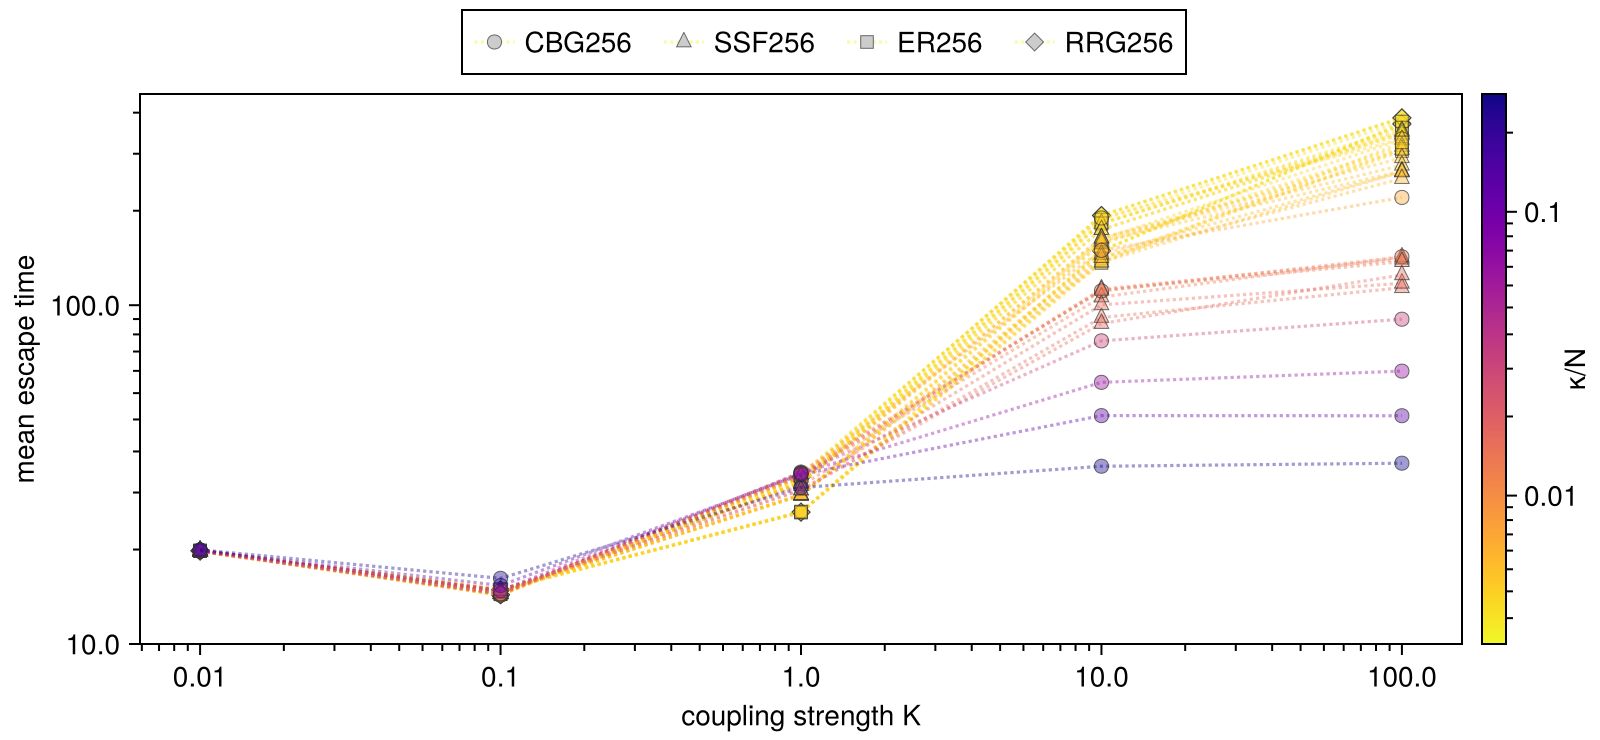

In [7]:
let ifsave=true, cmap=cgrad(:plasma, rev=true), crange=(3e-3, 0.26), cscale=log10
    (; d_κN, data) = prepare_data(t_input)

    fig = Figure(size=(800, 370), figure_padding=5)
    ax = Axis(fig[1, 1], 
        xlabel="coupling strength K", xgridvisible=false,
        xscale=log10, xtickformat=getlog10format(), 
        xminorticksvisible=true, xminorticks=IntervalsBetween(10),
        ylabel="mean escape time", ygridvisible=false,
        yscale=log10, ytickformat=getlog10format(), yticks=[10, 100, 1000],
        yminorticksvisible=true, yminorticks=IntervalsBetween(10),
    )
    ylims!(ax, low=10,)
    d_elem = Dict()
    for nw in keys(d_κN)
        if occursin("cbg256", nw)
            nwmodel = "CBG256"
            marker = :circle
        elseif occursin("ssf256", nw)
            nwmodel = "SSF256"
            marker = :utriangle
        elseif occursin("er256", nw)
            nwmodel = "ER256"
            marker = :rect
        elseif occursin("rrg256", nw)
            nwmodel = "RRG256"
            marker = :diamond
        else
            error("unexpected network model $nw")
        end
        # plot sctterline
        sl = scatterlines!(ax, data.K, data[:, nw], label=nw,
            linestyle=(:dot, :dense), markersize=10, linewidth=1.6,
            marker=marker, color=d_κN[nw], 
            strokewidth=0.5, strokecolor=(:gray20, 0.7),
            colormap=cgrad(cmap, alpha=0.4), colorrange=crange, colorscale=cscale,
        )
        # adjust rendering order
        translate!(sl, 0, 0, 1 + d_κN[nw])
        #if length(vec_elem) < 1 push!(vec_elem, sl) end
        d_elem[nwmodel] = sl
    end
    Colorbar(fig[1, 2], label="κ/N",
        colormap=cmap, limits=crange, scale=cscale, 
        ticks=10.0.^(-4:0), tickformat=getlog10format(),
        minorticksvisible=true, minorticks=IntervalsBetween(10),
        labelpadding=-10.0,
    )

    leglab = ["CBG256", "SSF256", "ER256", "RRG256"]
    Legend(fig[begin - 1, 1:2], 
        [d_elem[lab] => (; markercolor=:gray80) for lab in leglab], 
        leglab,
        orientation=:horizontal,
    )
    rowgap!(fig.layout, 10)
    colgap!(fig.layout, 10)
    # save figure
    if ifsave save("output/fig-deghet-met-vs-K.pdf", fig) end  # PDF for thesis
    display(fig)
end;